In [1]:
import pandas as pd
import numpy as np
import os
import pickle

In [2]:
all_df = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/data/disgent_2020/timecut/dga_time_uniport.csv')

## deepsvdd

In [50]:
root = '/itf-fi-ml/shared/users/ziyuzh/svm/results/'
paths = ['df_gnn_occsvm_pred','2019_occ_deep_svd_pred/pred.pkl']
for filename in os.listdir(os.path.join(root,paths[0])):
    disease = filename[:9]
    with open(os.path.join(root, paths[0],filename), "rb") as f:
        data1 = pickle.load(f)
    with open(os.path.join(root, paths[1],filename), "rb") as f:
        data2 = pickle.load(f)    
    intersec = set(data1['test_genes'][data1['true_label'] == 1]) & set(data2['test_genes'][data2['true_label'] == 1])
    real = set(data1['test_genes'][data1['true_label'] == 1])
    if intersec != real:
        print(disease,len(real)-len(intersec))

In [3]:
result_df = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/additinal_metrics_1and2percent.csv')

In [6]:
result_df[result_df['setting']=='2019_nn_all_pred']['method'].unique()

array(['seq_emb_port', 'early_fused_ppi', 'early_fused', 'ppi_emb_dw',
       'seq_emb_esm', 'ppi_emb_n2v', 'mid_fused', 'mid_fused_ppi',
       'literature_emb', 'late_fused_ppi', 'late_fused', 'ppi_emb_df'],
      dtype=object)

In [8]:
path = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_nn_all_pred'
filename = os.listdir(path)[0]
with open(os.path.join(path,filename), "rb") as f:
    data = pickle.load(f)

In [10]:
data.keys()

dict_keys(['true_label', 'test_genes', 'train_pos_genes', 'early_fused', 'late_fused', 'mid_fused', 'ppi_emb_n2v', 'ppi_emb_dw', 'ppi_emb_df', 'literature_emb', 'seq_emb_esm', 'seq_emb_port', 'early_fused_ppi', 'late_fused_ppi', 'mid_fused_ppi'])

In [21]:
root = '/itf-fi-ml/shared/users/ziyuzh/svm/results'
folders = ['2019_nn_oob','2019_nn_oob_ppi']

out_path_pred = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_nn_all_pred'
# os.makedirs(out_path_pred, exist_ok=True)

for filename in os.listdir('/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_nn_oob_pred'):
    summarized_dict = dict()
    for idx, folder in enumerate(folders):
        folder = folder+'_pred'
        root_path = os.path.join(root, folder)
        if 'pred.pkl' in os.listdir(root_path):
            root_path = os.path.join(root_path,'pred.pkl')
        with open(os.path.join(root_path,filename), "rb") as f:
            data = pickle.load(f)

        if folders[idx] == '2019_nn_oob':
            summarized_dict['late_fused'] = data['DL_later_avg'].copy()

        if folders[idx] == '2019_nn_oob_ppi':
            summarized_dict['late_fused_ppi'] = data['DL_later_avg'].copy()
    with open(os.path.join(out_path_pred,filename), "rb") as f:
        data_ori = pickle.load(f)
    data_ori['late_fused'] = summarized_dict['late_fused'] 
    data_ori['late_fused_ppi'] = summarized_dict['late_fused_ppi'] 

    with open(os.path.join(out_path_pred, filename), 'wb') as f:
        pickle.dump(data_ori, f)
        
    


## calculate additional metrics

In [ ]:
from rdkit.ML.Scoring.Scoring import CalcBEDROC
from sklearn.metrics import roc_auc_score

root = '/itf-fi-ml/shared/users/ziyuzh/svm/results/'
# paths = ['df_gnn_occsvm_pred','2019_nn_all_pred','2019_rf_renamed_pred','2019_mf_bag_2_pred','2019_occ_deep_svd_pred/pred.pkl']
# paths = ['2019_gnn_add_improvesage_pred']

# paths = ['2019_mf_add_pred']

# paths = ['2019_gnn_add_pred']
paths = ['2019_gcn_deoversmooth_less_smooth_pred']


# paths = ['2019_occ_deep_svd_pred/pred.pkl']

def top_recall(cut, y_scores, y_test):
    total_pos = np.sum(y_test == 1)
    if total_pos == 0:
        return 0.0
    top_idx = np.argsort(y_scores)[-cut:][::-1]
    TP = np.sum(y_test[top_idx] == 1)
    return TP / total_pos

result_df = pd.DataFrame(columns=['disease','setting','method','top_recall_150','succ_150','w_recall_150','top_recall_300','succ_300','w_recall_300','bedroc_150','bedroc_300','auroc'])

for filename in os.listdir(os.path.join(root,paths[0])):
    disease = filename[:9]
    for path in paths:
        with open(os.path.join(root, path,filename), "rb") as f:
            data = pickle.load(f)
        y_label = data['true_label']
        method = list(set(data.keys()) - set(['true_label', 'test_genes', 'train_pos_genes']))

        for setting in method:
            y_pred = data[setting]
            scores = np.column_stack((y_label, y_pred))  # Stack labels and scores as columns
            scores = scores[scores[:, 1].argsort()[::-1]]

            top_idx = np.argsort(y_pred)[::-1]
            res = []
            for threshold in [150,300]:
                succeed_rate = int(np.sum(y_label[top_idx][:threshold] == 1) > 0)

                true_positive_genes = data['test_genes'][y_label == 1]
                subdf = all_df[(all_df['disease_id']==disease)&(all_df['string_id']).isin(true_positive_genes)][['score','string_id']]
                if len(subdf) != len(true_positive_genes):
                    print('waring',subdf,disease)
                    break
                score_map = dict(zip(subdf['string_id'], subdf['score']))

                # Create new array with matching scores
                new_scores = np.array([score_map.get(gene, 0) for gene in data['test_genes']])
                weighted_recall = np.sum(new_scores[top_idx][:threshold])/subdf['score'].sum()

                res.extend([top_recall(threshold,y_pred,y_label),succeed_rate,weighted_recall])
            row = [disease, path, setting] + list(res)
            row.extend([CalcBEDROC(scores, col=0, alpha=160.9),CalcBEDROC(scores, col=0, alpha=80.45),roc_auc_score(y_label, y_pred)])

            result_df.loc[len(result_df)] = row


In [26]:
result_df = result_df[result_df['method'].str.contains('gcn')]

In [4]:
result_df.groupby('method').mean(numeric_only=True)

,top_recall_150,succ_150,w_recall_150,top_recall_300,succ_300,w_recall_300,bedroc_150,bedroc_300,auroc
method,,,,,,,,,
gcn_diffusion_2019_pca,0.140092,0.354167,0.150728,0.194583,0.479167,0.205547,0.098556,0.135492,0.702717
gcn_ppi_2019_dw_40,0.146870,0.333333,0.157792,0.291919,0.500000,0.308369,0.117602,0.181993,0.799339
gcn_uniport_bio,0.170031,0.395833,0.186905,0.249794,0.500000,0.267203,0.118250,0.175143,0.796602
gcn_uniport_esm,0.113720,0.291667,0.126610,0.144969,0.354167,0.159737,0.080903,0.117357,0.711460
gcn_uniport_ppi_2019,0.147882,0.354167,0.160487,0.275871,0.520833,0.294443,0.112175,0.170872,0.799727
gcn_uniport_seq,0.121527,0.354167,0.135760,0.184923,0.458333,0.197772,0.082849,0.125259,0.735601


In [27]:
result_df.groupby('method').mean(numeric_only=True)

,top_recall_150,succ_150,w_recall_150,top_recall_300,succ_300,w_recall_300,bedroc_150,bedroc_300,auroc
method,,,,,,,,,
gcn_diffusion_2019_pca,0.157656,0.375000,0.168934,0.257918,0.479167,0.270805,0.120926,0.176595,0.796032
gcn_ppi_2019_dw_40,0.125354,0.333333,0.136088,0.205380,0.437500,0.219600,0.100222,0.150154,0.779352
gcn_uniport_bio,0.121950,0.312500,0.130891,0.192810,0.416667,0.204415,0.097227,0.142317,0.775825
gcn_uniport_esm,0.103363,0.270833,0.111097,0.217019,0.395833,0.226795,0.076076,0.122763,0.740855
gcn_uniport_ppi_2019,0.123915,0.312500,0.134342,0.200295,0.416667,0.214112,0.096947,0.144791,0.778112
gcn_uniport_seq,0.128655,0.291667,0.137799,0.199116,0.354167,0.207985,0.073262,0.119212,0.741175


In [28]:
# result_df['setting'] = 'graphsage'
result_df['setting'] = 'gcn'
result_df['method'] = result_df['method'].str.split('_').str[1:].str.join('_')

/tmp/ipykernel_1392297/431679006.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_df['setting'] = 'gcn'
/tmp/ipykernel_1392297/431679006.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_df['method'] = result_df['method'].str.split('_').str[1:].str.join('_')


In [31]:
result_df

,disease,setting,method,top_recall_150,succ_150,w_recall_150,top_recall_300,succ_300,w_recall_300,bedroc_150,bedroc_300,auroc
0,ICD10_C16,gcn,seq_emb_port,0.12,1,0.161585,0.24,1,0.304878,8.171233e-02,0.145715,0.808905
3,ICD10_C16,gcn,seq_emb_esm,0.12,1,0.161585,0.24,1,0.304878,9.247747e-02,0.156186,0.806912
4,ICD10_C16,gcn,ppi_emb_n2v,0.20,1,0.259146,0.32,1,0.396341,1.368059e-01,0.218398,0.853150
5,ICD10_C16,gcn,ppi_emb_dw,0.20,1,0.259146,0.28,1,0.350610,1.300663e-01,0.207797,0.854263
7,ICD10_C16,gcn,literature_emb,0.20,1,0.259146,0.40,1,0.484756,1.354489e-01,0.223434,0.877199
...,...,...,...,...,...,...,...,...,...,...,...,...
567,ICD10_G43,gcn,seq_emb_esm,0.00,0,0.000000,0.00,0,0.000000,1.081541e-11,0.000002,0.638304
568,ICD10_G43,gcn,ppi_emb_n2v,0.00,0,0.000000,0.00,0,0.000000,6.976763e-08,0.000133,0.679595
569,ICD10_G43,gcn,ppi_emb_dw,0.00,0,0.000000,0.00,0,0.000000,1.666501e-09,0.000027,0.711949
571,ICD10_G43,gcn,literature_emb,0.00,0,0.000000,0.00,0,0.000000,6.627426e-08,0.000129,0.696530


In [30]:
result_df['method'] = result_df['method'].replace({
    'diffusion_2019_pca': 'ppi_emb_df',
    'uniport_ppi_2019':'ppi_emb_n2v',
    'diffusion_2019_pca': 'ppi_emb_df',
    'uniport_bio':'literature_emb',
    'ppi_2019_dw_40':'ppi_emb_dw',
    'uniport_esm':'seq_emb_esm',
    'uniport_seq':'seq_emb_port'
})

/tmp/ipykernel_1392297/541366685.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_df['method'] = result_df['method'].replace({


In [32]:
result_df_ori = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/additinal_metrics_1and2percent.csv')
print(len(result_df_ori))
result_df_ori = result_df_ori[(result_df_ori['method']!='GCNs')&(result_df_ori['method']!='Graph_sage')]
# result_df_ori = result_df_ori[result_df_ori['setting']!='2019_mf_bag_2_pred']
len(result_df_ori)

2208


2208

In [33]:
result_df['setting'].unique(),result_df_ori['setting'].unique()

(array(['gcn'], dtype=object),
 array(['df_gnn_occsvm_pred', '2019_rf_renamed_pred',
        '2019_occ_deep_svd_pred/pred.pkl', '2019_nn_all_pred',
        '2019_mf_add_pred', 'graphsage'], dtype=object))

In [34]:
result_df['method'].unique(),result_df_ori['method'].unique()

(array(['seq_emb_port', 'seq_emb_esm', 'ppi_emb_n2v', 'ppi_emb_dw',
        'literature_emb', 'ppi_emb_df'], dtype=object),
 array(['early_fused_ppi', 'early_fused', 'ppi_emb_dw', 'seq_emb_esm',
        'ppi_emb_n2v', 'mid_geo_fused_ppi', 'occ_svm', 'literature_emb',
        'late_fused', 'seq_emb_port', 'mid_linear_fused',
        'mid_linear_fused_ppi', 'mid_geo_fused', 'late_fused_ppi',
        'ppi_emb_df', 'uniport_ppi_2019', 'mid_fused', 'mid_fused_ppi'],
       dtype=object))

In [35]:
len(result_df),len(result_df_ori)

(288, 2208)

In [36]:
stacked = pd.concat([result_df_ori, result_df], axis=0, ignore_index=True)
len(stacked)

2496

In [1]:
import pandas as pd
stacked = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/additinal_metrics_1and2percent.csv')
len(stacked)

2016

In [37]:
stacked['disease'].unique()

array(['ICD10_C16', 'ICD10_F31', 'ICD10_C43', 'ICD10_I10', 'ICD10_J45',
       'ICD10_I63', 'ICD10_C18', 'ICD10_G30', 'ICD10_E66', 'ICD10_M34',
       'ICD10_G10', 'ICD10_D66', 'ICD10_G40', 'ICD10_N17', 'ICD10_C50',
       'ICD10_E11', 'ICD10_C53', 'ICD10_M41', 'ICD10_I25', 'ICD10_F20',
       'ICD10_N04', 'ICD10_I50', 'ICD10_F01', 'ICD10_K51', 'ICD10_M32',
       'ICD10_C67', 'ICD10_I70', 'ICD10_N18', 'ICD10_I42', 'ICD10_J80',
       'ICD10_J62', 'ICD10_C23', 'ICD10_G91', 'ICD10_D83', 'ICD10_N80',
       'ICD10_D57', 'ICD10_L20', 'ICD10_I26', 'ICD10_G20', 'ICD10_F72',
       'ICD10_N97', 'ICD10_N46', 'ICD10_F90', 'ICD10_G24', 'ICD10_C81',
       'ICD10_L40', 'ICD10_K44', 'ICD10_G43'], dtype=object)

In [19]:
stacked = stacked[stacked['disease']!='ICD10_C45']

In [38]:
stacked['setting'].unique(),stacked['method'].unique()

(array(['df_gnn_occsvm_pred', '2019_rf_renamed_pred',
        '2019_occ_deep_svd_pred/pred.pkl', '2019_nn_all_pred',
        '2019_mf_add_pred', 'graphsage', 'gcn'], dtype=object),
 array(['early_fused_ppi', 'early_fused', 'ppi_emb_dw', 'seq_emb_esm',
        'ppi_emb_n2v', 'mid_geo_fused_ppi', 'occ_svm', 'literature_emb',
        'late_fused', 'seq_emb_port', 'mid_linear_fused',
        'mid_linear_fused_ppi', 'mid_geo_fused', 'late_fused_ppi',
        'ppi_emb_df', 'uniport_ppi_2019', 'mid_fused', 'mid_fused_ppi'],
       dtype=object))

In [39]:
stacked.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/additinal_metrics_1and2percent.csv',index=False)

In [41]:
stacked = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/additinal_metrics_1and2percent.csv')
stacked

,disease,setting,method,top_recall_150,succ_150,w_recall_150,top_recall_300,succ_300,w_recall_300,bedroc_150,bedroc_300,auroc
0,ICD10_C16,df_gnn_occsvm_pred,early_fused_ppi,0.28,1,0.326220,0.40,1,0.472561,2.069869e-01,0.287726,0.890605
1,ICD10_C16,df_gnn_occsvm_pred,early_fused,0.20,1,0.198171,0.32,1,0.332317,1.056337e-01,0.178621,0.861021
2,ICD10_C16,df_gnn_occsvm_pred,ppi_emb_dw,0.32,1,0.393293,0.40,1,0.472561,2.037689e-01,0.300176,0.895978
3,ICD10_C16,df_gnn_occsvm_pred,seq_emb_esm,0.04,1,0.027439,0.12,1,0.109756,2.556261e-02,0.060936,0.735871
4,ICD10_C16,df_gnn_occsvm_pred,ppi_emb_n2v,0.32,1,0.393293,0.48,1,0.564024,2.400080e-01,0.328343,0.884768
...,...,...,...,...,...,...,...,...,...,...,...,...
2491,ICD10_G43,gcn,seq_emb_esm,0.00,0,0.000000,0.00,0,0.000000,1.081541e-11,0.000002,0.638304
2492,ICD10_G43,gcn,ppi_emb_n2v,0.00,0,0.000000,0.00,0,0.000000,6.976763e-08,0.000133,0.679595
2493,ICD10_G43,gcn,ppi_emb_dw,0.00,0,0.000000,0.00,0,0.000000,1.666501e-09,0.000027,0.711949
2494,ICD10_G43,gcn,literature_emb,0.00,0,0.000000,0.00,0,0.000000,6.627426e-08,0.000129,0.696530


In [42]:
bio = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/bio_sim_add.csv')
bio

,feature,cutoff_100,cutoff_200,cutoff_300,cutoff_0.01,disease,method,setting
0,early_fused,0.242775,0.208370,0.197614,0.220574,ICD10_C16,early_fused,df_gnn_occsvm_pred
1,early_fused_ppi,0.190202,0.165779,0.161484,0.170398,ICD10_C16,early_fused_ppi,df_gnn_occsvm_pred
2,late_fused,0.236063,0.189260,0.179952,0.186959,ICD10_C16,late_fused,df_gnn_occsvm_pred
3,late_fused_ppi,0.190309,0.165904,0.151239,0.170379,ICD10_C16,late_fused_ppi,df_gnn_occsvm_pred
4,ppi_emb_n2v,0.194161,0.172564,0.164926,0.178091,ICD10_C16,ppi_emb_n2v,df_gnn_occsvm_pred
...,...,...,...,...,...,...,...,...
2491,gcn_ppi_2019_dw_40,0.010129,0.012552,0.012557,0.011029,ICD10_G43,ppi_emb_dw,gcn
2492,gcn_uniport_bio,0.012346,0.012579,0.015636,0.013979,ICD10_G43,literature_emb,gcn
2493,gcn_uniport_seq,0.008828,0.008387,0.009462,0.009233,ICD10_G43,seq_emb_port,gcn
2494,gcn_uniport_esm,0.009167,0.009722,0.011678,0.008830,ICD10_G43,seq_emb_esm,gcn


In [55]:
result_df2=pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/additinal_metrics.csv')

In [56]:
df_combined = pd.concat([result_df, result_df2], ignore_index=True)
df_combined

,disease,setting,method,succ_1%,w_recall_1%,succ_5%,w_recall_5%,succ_10%,w_recall_10%,succ_30%,w_recall_30%
0,ICD10_C16,2019_occ_deep_svd_pred/pred.pkl,uniport_ppi_2019,1,0.097345,1,0.365782,1,0.519174,1,0.867257
1,ICD10_F31,2019_occ_deep_svd_pred/pred.pkl,uniport_ppi_2019,0,0.000000,1,0.068627,1,0.245098,1,0.539216
2,ICD10_C43,2019_occ_deep_svd_pred/pred.pkl,uniport_ppi_2019,0,0.000000,0,0.000000,0,0.000000,1,0.578947
3,ICD10_I10,2019_occ_deep_svd_pred/pred.pkl,uniport_ppi_2019,1,0.124224,1,0.316770,1,0.540373,1,0.788820
4,ICD10_J45,2019_occ_deep_svd_pred/pred.pkl,uniport_ppi_2019,1,0.370370,1,0.666667,1,0.666667,1,1.000000
...,...,...,...,...,...,...,...,...,...,...,...
1771,ICD10_G43,2019_rf_renamed_pred,ppi_emb_n2v,0,0.000000,0,0.000000,0,0.000000,1,1.000000
1772,ICD10_G43,2019_rf_renamed_pred,ppi_emb_dw,0,0.000000,0,0.000000,0,0.000000,1,0.687500
1773,ICD10_G43,2019_rf_renamed_pred,seq_emb_esm,0,0.000000,0,0.000000,1,0.166667,1,0.812500
1774,ICD10_G43,2019_rf_renamed_pred,ppi_emb_df,0,0.000000,0,0.000000,1,0.500000,1,0.500000


In [57]:
df_combined.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/additinal_metrics.csv',index=False)

In [58]:
result_df = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/additinal_metrics.csv')
result_df

,disease,setting,method,succ_1%,w_recall_1%,succ_5%,w_recall_5%,succ_10%,w_recall_10%,succ_30%,w_recall_30%
0,ICD10_C16,2019_occ_deep_svd_pred/pred.pkl,uniport_ppi_2019,1,0.097345,1,0.365782,1,0.519174,1,0.867257
1,ICD10_F31,2019_occ_deep_svd_pred/pred.pkl,uniport_ppi_2019,0,0.000000,1,0.068627,1,0.245098,1,0.539216
2,ICD10_C43,2019_occ_deep_svd_pred/pred.pkl,uniport_ppi_2019,0,0.000000,0,0.000000,0,0.000000,1,0.578947
3,ICD10_I10,2019_occ_deep_svd_pred/pred.pkl,uniport_ppi_2019,1,0.124224,1,0.316770,1,0.540373,1,0.788820
4,ICD10_J45,2019_occ_deep_svd_pred/pred.pkl,uniport_ppi_2019,1,0.370370,1,0.666667,1,0.666667,1,1.000000
...,...,...,...,...,...,...,...,...,...,...,...
1771,ICD10_G43,2019_rf_renamed_pred,ppi_emb_n2v,0,0.000000,0,0.000000,0,0.000000,1,1.000000
1772,ICD10_G43,2019_rf_renamed_pred,ppi_emb_dw,0,0.000000,0,0.000000,0,0.000000,1,0.687500
1773,ICD10_G43,2019_rf_renamed_pred,seq_emb_esm,0,0.000000,0,0.000000,1,0.166667,1,0.812500
1774,ICD10_G43,2019_rf_renamed_pred,ppi_emb_df,0,0.000000,0,0.000000,1,0.500000,1,0.500000


In [59]:
grouped_mean = (
    result_df
    .groupby(['setting', 'method'], as_index=False)
    .mean(numeric_only=True)
)

## occ

In [98]:
selected_pairs = [['df_gnn_occsvm_pred','occ_svm'],
            ['df_gnn_occsvm_pred','ppi_emb_n2v'],
            ['2019_nn_all_pred','ppi_emb_n2v'],
            ['2019_occ_deep_svd_pred/pred.pkl','uniport_ppi_2019']]

subresults = grouped_mean.set_index(['setting', 'method']).loc[selected_pairs].reset_index()
subresults['method'] = ['occ_svm','bagging_svm','bagging_dnn','occ_dnn']
subresults = subresults[['method', 'succ_1%', 'w_recall_1%', 'succ_5%', 'w_recall_5%',
       'succ_10%', 'w_recall_10%', 'succ_30%', 'w_recall_30%']].round(3)
num_cols = subresults.select_dtypes(include="number").columns

display(subresults.style
        .format({c: "{:.2f}" for c in num_cols})
        .highlight_max(subset=num_cols,axis=0,props="color: red;")
        .set_table_styles([{'selector': 'th, td', 'props': [('max-width', '80px')]}]))


,method,succ_1%,w_recall_1%,succ_5%,w_recall_5%,succ_10%,w_recall_10%,succ_30%,w_recall_30%
0,occ_svm,0.31,0.10,0.44,0.23,0.56,0.34,0.85,0.63
1,bagging_svm,0.40,0.20,0.67,0.41,0.79,0.56,0.96,0.79
2,bagging_dnn,0.23,0.07,0.58,0.33,0.77,0.50,0.96,0.71
3,occ_dnn,0.35,0.11,0.65,0.29,0.77,0.38,0.94,0.66


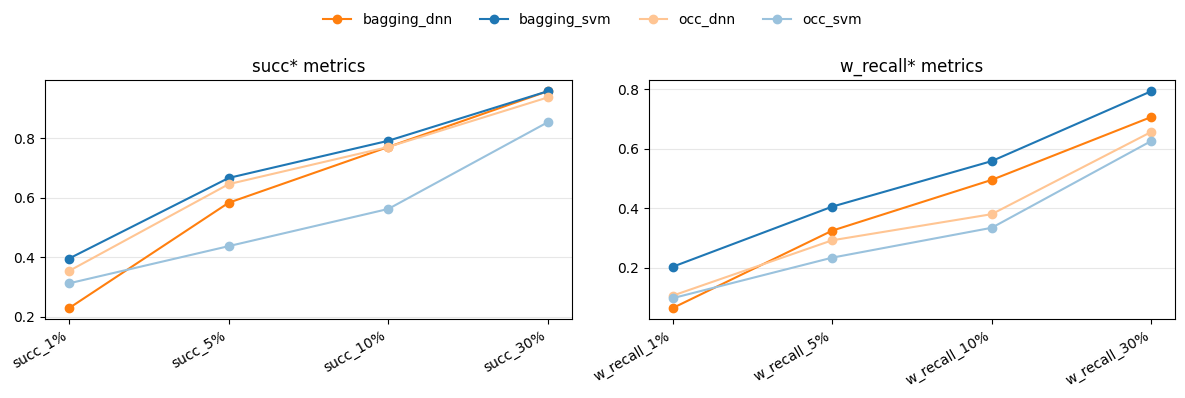

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def lighten(color, amount=0.55):
    rgb = np.array(mcolors.to_rgb(color))
    return tuple(rgb + (1 - rgb) * amount)

# Select columns
succ_cols = [c for c in subresults.columns if c.startswith("succ")]
recall_cols = [c for c in subresults.columns if c.startswith("w_recall")]

# Average over settings (cleaner visual)
summary = subresults.groupby("method")[succ_cols + recall_cols].mean()

# Base colors
base = {
    "svm": "C0",
    "dnn": "C1",
}

# Assign colors (occ lighter)
method_colors = {}
for m in summary.index:
    family = "svm" if "svm" in m else "dnn"
    c = base[family]
    method_colors[m] = lighten(c) if m.startswith("occ_") else c

# ---- Create horizontal stacked plots ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

# --- Plot 1: succ ---
x1 = np.arange(len(succ_cols))
for m in summary.index:
    axes[0].plot(x1, summary.loc[m, succ_cols], marker='o',
                 label=m, color=method_colors[m])

axes[0].set_xticks(x1)
axes[0].set_xticklabels(succ_cols, rotation=30, ha='right')
axes[0].set_title("succ* metrics")
axes[0].grid(True, axis="y", alpha=0.3)

# --- Plot 2: w_recall ---
x2 = np.arange(len(recall_cols))
for m in summary.index:
    axes[1].plot(x2, summary.loc[m, recall_cols], marker='o',
                 label=m, color=method_colors[m])

axes[1].set_xticks(x2)
axes[1].set_xticklabels(recall_cols, rotation=30, ha='right')
axes[1].set_title("w_recall* metrics")
axes[1].grid(True, axis="y", alpha=0.3)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()



## features

In [87]:
selected_features = ['ppi_emb_df','ppi_emb_dw', 'ppi_emb_n2v', 'literature_emb','seq_emb_esm', 'seq_emb_port']

subresults = grouped_mean[(grouped_mean['setting']=='df_gnn_occsvm_pred')&(grouped_mean['method'].isin(selected_features))]
subresults = subresults[['method', 'succ_1%', 'w_recall_1%', 'succ_5%', 'w_recall_5%',
       'succ_10%', 'w_recall_10%', 'succ_30%', 'w_recall_30%']].round(3)
num_cols = subresults.select_dtypes(include="number").columns

display(subresults.style
        .format({c: "{:.2f}" for c in num_cols})
        .highlight_max(subset=num_cols,axis=0,props="color: red;")
        .set_table_styles([{'selector': 'th, td', 'props': [('max-width', '80px')]}]))



,method,succ_1%,w_recall_1%,succ_5%,w_recall_5%,succ_10%,w_recall_10%,succ_30%,w_recall_30%
26,literature_emb,0.33,0.13,0.60,0.31,0.71,0.41,0.88,0.65
32,ppi_emb_df,0.48,0.23,0.73,0.46,0.77,0.53,0.96,0.78
33,ppi_emb_dw,0.35,0.18,0.67,0.43,0.83,0.59,0.96,0.79
34,ppi_emb_n2v,0.40,0.20,0.67,0.41,0.79,0.56,0.96,0.79
35,seq_emb_esm,0.31,0.10,0.48,0.20,0.62,0.30,0.85,0.57
36,seq_emb_port,0.29,0.12,0.54,0.25,0.67,0.31,0.79,0.56


In [80]:
def plot_features(subresults):
    succ_cols = [c for c in subresults.columns if c.startswith("succ")]
    recall_cols = [c for c in subresults.columns if c.startswith("w_recall")]

    # Average over settings
    summary = subresults.groupby("method")[succ_cols + recall_cols].mean()


    # -------- Plot 1: succ* metrics --------
    plt.figure()

    x1 = np.arange(len(succ_cols))

    for m in summary.index:
        plt.plot(x1, summary.loc[m, succ_cols], marker='o', label=m)

    plt.xticks(x1, succ_cols, rotation=30, ha='right')
    plt.title("succ* metrics")
    plt.grid(True, axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


    # -------- Plot 2: w_recall* metrics --------
    plt.figure()

    x2 = np.arange(len(recall_cols))

    for m in summary.index:
        plt.plot(x2, summary.loc[m, recall_cols], marker='o', label=m)

    plt.xticks(x2, recall_cols, rotation=30, ha='right')
    plt.title("w_recall* metrics")
    plt.grid(True, axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


,method,succ_1%,w_recall_1%,succ_5%,w_recall_5%,succ_10%,w_recall_10%,succ_30%,w_recall_30%
5,literature_emb,0.29,0.10,0.56,0.29,0.71,0.39,0.90,0.61
8,ppi_emb_df,0.48,0.28,0.69,0.46,0.81,0.58,0.94,0.75
9,ppi_emb_dw,0.40,0.16,0.65,0.38,0.73,0.49,0.96,0.76
10,ppi_emb_n2v,0.23,0.07,0.58,0.33,0.77,0.50,0.96,0.71
11,seq_emb_esm,0.12,0.03,0.40,0.18,0.58,0.24,0.81,0.46
12,seq_emb_port,0.21,0.09,0.40,0.18,0.60,0.26,0.81,0.52


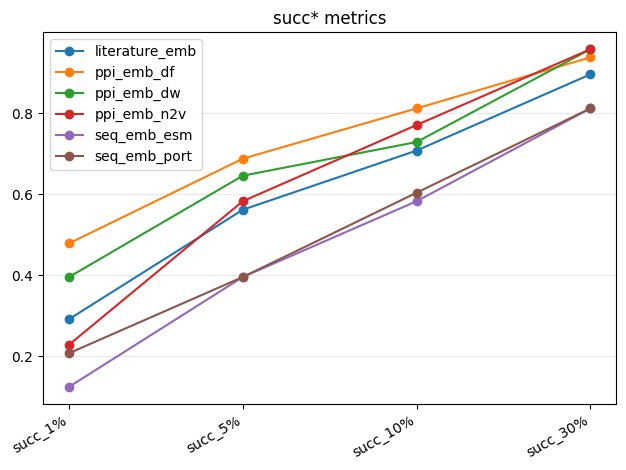

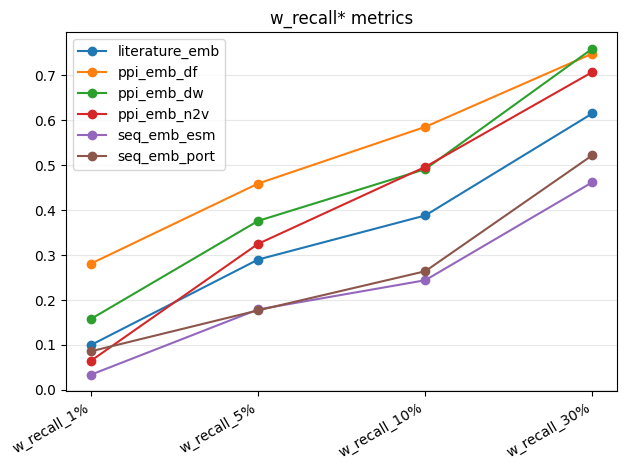

In [86]:

subresults = grouped_mean[(grouped_mean['setting']=='2019_nn_all_pred')&(grouped_mean['method'].isin(selected_features))]

subresults = subresults[['method', 'succ_1%', 'w_recall_1%', 'succ_5%', 'w_recall_5%',
       'succ_10%', 'w_recall_10%', 'succ_30%', 'w_recall_30%']].round(3)
num_cols = subresults.select_dtypes(include="number").columns

display(subresults.style
        .format({c: "{:.2f}" for c in num_cols})
        .highlight_max(subset=num_cols,axis=0,props="color: red;")
        .set_table_styles([{'selector': 'th, td', 'props': [('max-width', '80px')]}]))

plot_features(subresults)

,method,succ_1%,w_recall_1%,succ_5%,w_recall_5%,succ_10%,w_recall_10%,succ_30%,w_recall_30%
14,literature_emb,0.31,0.13,0.62,0.32,0.69,0.40,0.88,0.61
15,ppi_emb_df,0.38,0.16,0.67,0.44,0.77,0.52,0.92,0.75
16,ppi_emb_dw,0.40,0.19,0.67,0.41,0.77,0.51,0.94,0.73
17,ppi_emb_n2v,0.33,0.18,0.62,0.38,0.79,0.53,0.90,0.70
18,seq_emb_esm,0.25,0.09,0.46,0.15,0.60,0.25,0.79,0.48
19,seq_emb_port,0.27,0.11,0.50,0.20,0.60,0.30,0.75,0.50


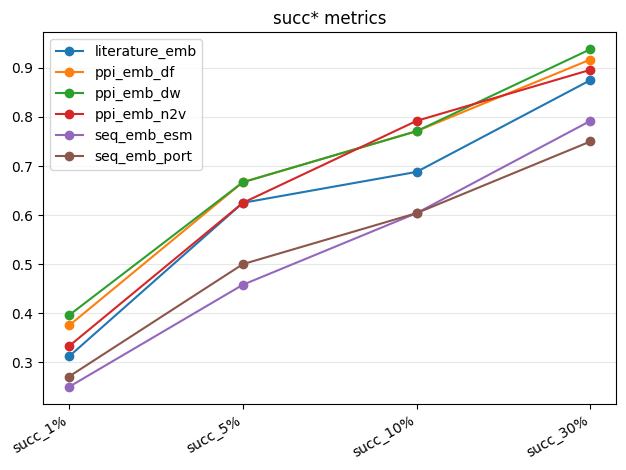

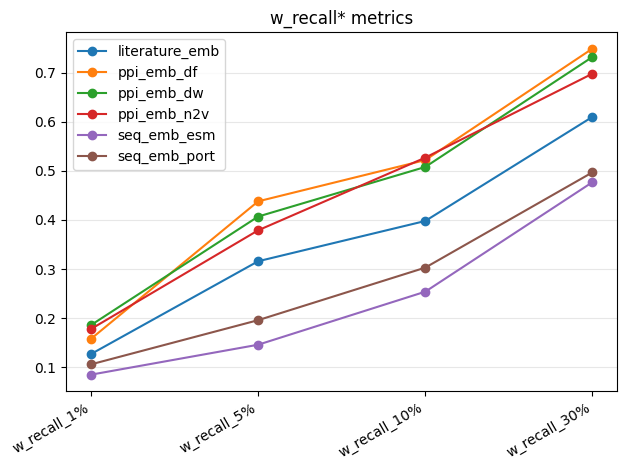

In [85]:

subresults = grouped_mean[(grouped_mean['setting']=='2019_rf_renamed_pred')&(grouped_mean['method'].isin(selected_features))]

subresults = subresults[['method', 'succ_1%', 'w_recall_1%', 'succ_5%', 'w_recall_5%',
       'succ_10%', 'w_recall_10%', 'succ_30%', 'w_recall_30%']].round(3)
num_cols = subresults.select_dtypes(include="number").columns

display(subresults.style
        .format({c: "{:.2f}" for c in num_cols})
        .highlight_max(subset=num_cols,axis=0,props="color: red;")
        .set_table_styles([{'selector': 'th, td', 'props': [('max-width', '80px')]}]))

plot_features(subresults)

## models

,method,succ_1%,w_recall_1%,succ_5%,w_recall_5%,succ_10%,w_recall_10%,succ_30%,w_recall_30%
0,svm,0.40,0.20,0.67,0.41,0.79,0.56,0.96,0.79
1,graph_sage,0.42,0.20,0.69,0.42,0.79,0.53,0.94,0.75
2,gcn,0.33,0.14,0.62,0.37,0.73,0.50,0.94,0.73
3,dnn,0.23,0.07,0.58,0.33,0.77,0.50,0.96,0.71
4,rf,0.33,0.18,0.62,0.38,0.79,0.53,0.90,0.70
5,mf,0.42,0.19,0.60,0.35,0.77,0.51,0.98,0.76


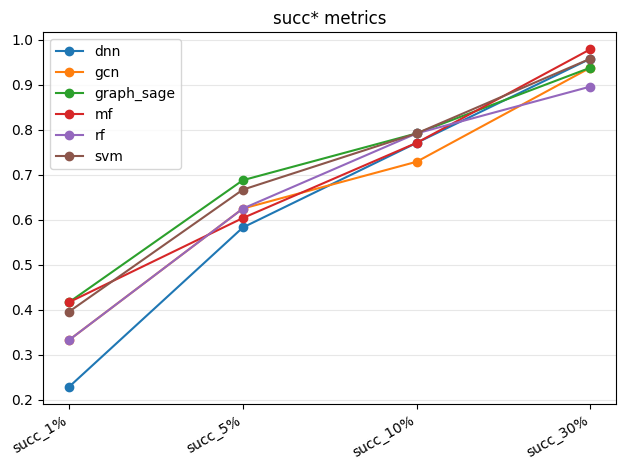

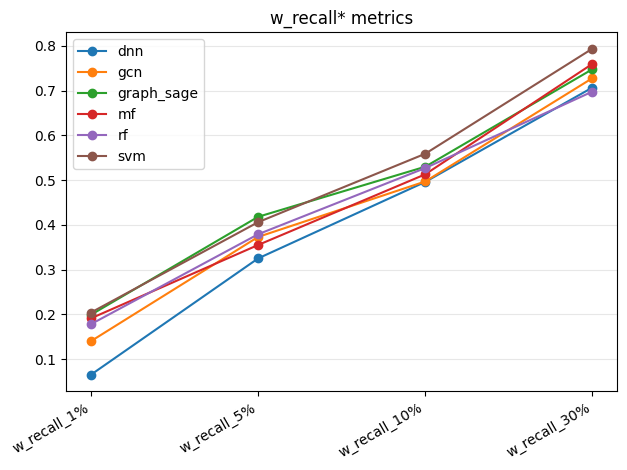

In [ ]:
selected_pairs = [['df_gnn_occsvm_pred','ppi_emb_n2v'],
                  ['df_gnn_occsvm_pred','Graph_sage'],
                  ['df_gnn_occsvm_pred','GCNs'],
            ['2019_nn_all_pred','ppi_emb_n2v'],
            ['2019_rf_renamed_pred','ppi_emb_n2v'],
            ['2019_mf_bag_2_pred','uniport_ppi_2019']
            ]
subresults = grouped_mean.set_index(['setting', 'method']).loc[selected_pairs].reset_index()
subresults['method'] = ['svm','graph_sage','gcn','dnn','rf','mf']
subresults = subresults[['method', 'succ_1%', 'w_recall_1%', 'succ_5%', 'w_recall_5%',
       'succ_10%', 'w_recall_10%', 'succ_30%', 'w_recall_30%']].round(3)
num_cols = subresults.select_dtypes(include="number").columns

display(subresults.style
        .format({c: "{:.2f}" for c in num_cols})
        .highlight_max(subset=num_cols,axis=0,props="color: red;")
        .set_table_styles([{'selector': 'th, td', 'props': [('max-width', '80px')]}]))

plot_features(subresults)

## fusion

,method,succ_1%,w_recall_1%,succ_5%,w_recall_5%,succ_10%,w_recall_10%,succ_30%,w_recall_30%
22,early_fused,0.31,0.13,0.60,0.31,0.73,0.46,0.90,0.72
23,early_fused_ppi,0.42,0.22,0.67,0.40,0.83,0.60,0.94,0.77
24,late_fused,0.40,0.19,0.73,0.42,0.79,0.55,0.92,0.78
25,late_fused_ppi,0.38,0.20,0.65,0.41,0.83,0.59,0.96,0.79
27,mid_geo_fused,0.40,0.20,0.67,0.39,0.83,0.57,0.94,0.78
28,mid_geo_fused_ppi,0.44,0.26,0.62,0.42,0.83,0.61,0.96,0.79
29,mid_linear_fused,0.44,0.23,0.65,0.42,0.75,0.51,0.92,0.78
30,mid_linear_fused_ppi,0.44,0.23,0.67,0.41,0.81,0.58,0.96,0.80


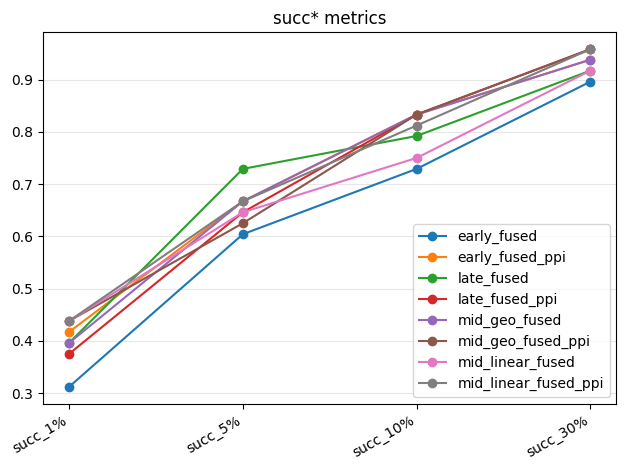

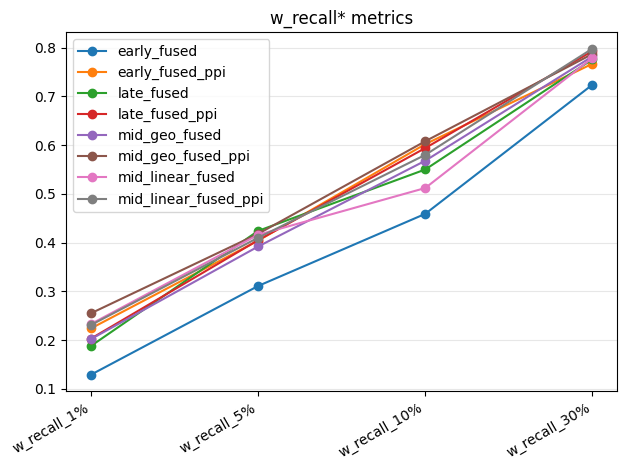

In [96]:
selected_features = ['early_fused', 'early_fused_ppi', 'late_fused', 'late_fused_ppi','mid_fused', 'mid_fused_ppi', 'mid_geo_fused_ppi',
       'mid_linear_fused', 'mid_linear_fused_ppi','mid_geo_fused']
subresults = grouped_mean[(grouped_mean['setting']=='df_gnn_occsvm_pred')&(grouped_mean['method'].isin(selected_features))].copy()

subresults = subresults[['method', 'succ_1%', 'w_recall_1%', 'succ_5%', 'w_recall_5%',
       'succ_10%', 'w_recall_10%', 'succ_30%', 'w_recall_30%']].round(3)
num_cols = subresults.select_dtypes(include="number").columns

display(subresults.style
        .format({c: "{:.2f}" for c in num_cols})
        .highlight_max(subset=num_cols,axis=0,props="color: red;")
        .set_table_styles([{'selector': 'th, td', 'props': [('max-width', '80px')]}]))

plot_features(subresults)


,method,succ_1%,w_recall_1%,succ_5%,w_recall_5%,succ_10%,w_recall_10%,succ_30%,w_recall_30%
1,early_fused,0.19,0.07,0.50,0.24,0.65,0.34,0.88,0.59
2,early_fused_ppi,0.40,0.20,0.67,0.41,0.79,0.56,0.96,0.78
3,late_fused,0.38,0.18,0.65,0.37,0.81,0.53,0.92,0.71
4,late_fused_ppi,0.29,0.11,0.52,0.27,0.60,0.38,0.79,0.55
6,mid_fused,0.50,0.24,0.69,0.43,0.77,0.54,0.94,0.75
7,mid_fused_ppi,0.42,0.20,0.69,0.46,0.79,0.56,0.94,0.75


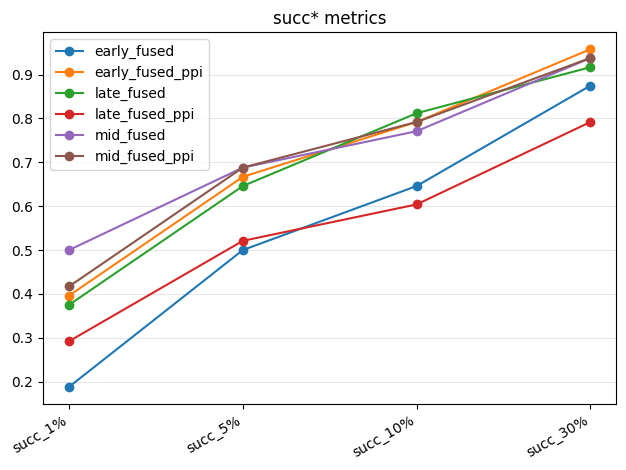

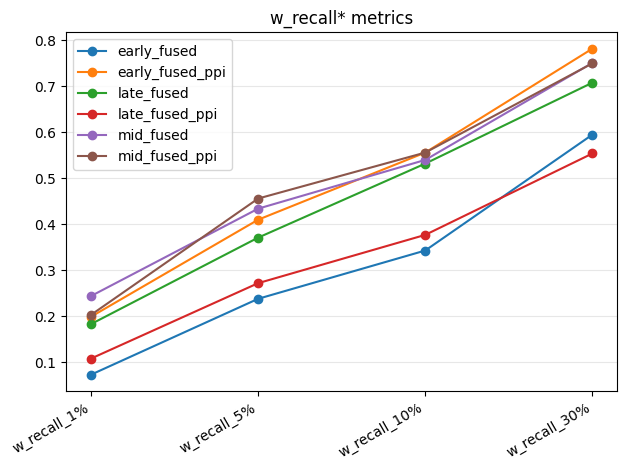

In [97]:
subresults = grouped_mean[(grouped_mean['setting']=='2019_nn_all_pred')&(grouped_mean['method'].isin(selected_features))].copy()

subresults = subresults[['method', 'succ_1%', 'w_recall_1%', 'succ_5%', 'w_recall_5%',
       'succ_10%', 'w_recall_10%', 'succ_30%', 'w_recall_30%']].round(3)
num_cols = subresults.select_dtypes(include="number").columns

display(subresults.style
        .format({c: "{:.2f}" for c in num_cols})
        .highlight_max(subset=num_cols,axis=0,props="color: red;")
        .set_table_styles([{'selector': 'th, td', 'props': [('max-width', '80px')]}]))

plot_features(subresults)